# Classification Results Summary

This notebook summarises the locked ADHD/autism frame-classification layer for reporting. It does not train or apply a classifier; it reads the existing frame-label outputs and writes compact tables, a LaTeX validation table, and one report-ready composition figure.


## Setup

The figure uses publication year (`lsc_year`) because the frame labels are attached to the shared LSC context table. `substantive_other` remains in the tables but is omitted from the figure because it is sparse and not central to the clinical/lived-experience contrast.


In [1]:
from __future__ import annotations

from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from matplotlib.lines import Line2D
from scipy import stats

pd.set_option("display.max_columns", 120)
pd.set_option("display.max_colwidth", 160)
plt.rcParams.update(
    {
        "figure.facecolor": "white",
        "axes.facecolor": "white",
        "axes.edgecolor": "#263238",
        "axes.labelcolor": "#263238",
        "axes.titlecolor": "#263238",
        "axes.spines.top": False,
        "axes.spines.right": False,
        "axes.grid": True,
        "grid.color": "#D7DEE2",
        "grid.linewidth": 0.8,
        "grid.alpha": 0.7,
        "font.family": "DejaVu Sans",
        "font.size": 10.5,
        "legend.frameon": False,
        "xtick.color": "#263238",
        "ytick.color": "#263238",
    }
)


def find_project_root(start: Path) -> Path:
    for path in [start, *start.parents]:
        if (path / "configs/commoncrawl_collection.yaml").exists() and (path / "data").exists():
            return path
    raise FileNotFoundError("Could not locate repository root from current working directory.")


PROJECT_ROOT = find_project_root(Path.cwd())
CLASSIFICATION_DIR = PROJECT_ROOT / "data/processed/lsc/classification"
TARGET_POOL_PATH = PROJECT_ROOT / "data/interim/lsc/classification/frame_target_context_pool.csv"
LABEL_PATH = CLASSIFICATION_DIR / "lsc_target_context_frame_labels.csv"
COUNTS_PATH = CLASSIFICATION_DIR / "lsc_frame_counts_by_year_unit.csv"
METRICS_PATH = CLASSIFICATION_DIR / "frame_classifier_validation_metrics.csv"
TABLE_DIR = PROJECT_ROOT / "reports/tables/lsc/classification"
FIGURE_DIR = PROJECT_ROOT / "reports/figures/lsc/classification"
FRAME_BALANCE_BOOTSTRAP_PATH = TABLE_DIR / "lsc_classification_frame_balance_bootstrap.csv"
FULL_COMPOSITION_PERIOD_PATH = TABLE_DIR / "lsc_classification_full_composition_periods.csv"
FRAME_TIME_TREND_PATH = TABLE_DIR / "lsc_classification_frame_time_trends.csv"
FRAME_TIME_WEIGHTED_TREND_PATH = TABLE_DIR / "lsc_classification_frame_time_trends_probability_weighted.csv"
FRAME_TIME_TREND_TABLE_PATH = TABLE_DIR / "lsc_classification_frame_time_trends.tex"
for path in [TABLE_DIR, FIGURE_DIR]:
    path.mkdir(parents=True, exist_ok=True)

EXPECTED_CODEBOOK_VERSION = "v0.4"
TARGET_UNITS = ["ADHD", "Autism"]
CLEAR_FRAME_FRAMES = ["clinical_only", "lived_only"]
APPENDIX_FRAMES = [
    "clinical_only",
    "lived_only",
    "mixed",
    "non_substantive_or_insufficient",
    "substantive_other",
]
APPENDIX_PERIODS = {
    "early_pct": (2014, 2017),
    "late_pct": (2022, 2026),
}
DW_AUTOCORRELATION_LOW = 1.25
DW_AUTOCORRELATION_HIGH = 2.75
BOOTSTRAP_REPETITIONS = 500
RANDOM_SEED = 20260708
FRAME_LABELS = {
    "clinical_only": "Clinical/disorder",
    "lived_only": "Lived experience",
    "mixed": "Mixed",
    "non_substantive_or_insufficient": "Non-substantive",
    "substantive_other": "Substantive other",
}
FRAME_COLOURS = {
    "clinical_only": "#4F8DB3",
    "lived_only": "#C98263",
    "mixed": "#79A889",
    "non_substantive_or_insufficient": "#B8C0C5",
    "substantive_other": "#A998C9",
}
TARGET_COLOURS = {
    "ADHD": "#2F6F9F",
    "Autism": "#B66A4A",
}
TARGET_MARKERS = {
    "ADHD": "o",
    "Autism": "s",
}

## Load and Validate Inputs

The target pool and processed frame-label file should refer to the same context IDs. The classifier metadata should also report the locked codebook version.


In [2]:
labels = pd.read_csv(LABEL_PATH)
counts = pd.read_csv(COUNTS_PATH)
metrics = pd.read_csv(METRICS_PATH)
target_pool = pd.read_csv(TARGET_POOL_PATH, usecols=["context_id"])

if set(labels["context_id"]) != set(target_pool["context_id"]):
    raise ValueError("Target pool and frame labels do not contain the same context IDs.")
if labels["context_id"].duplicated().any():
    raise ValueError("Frame labels contain duplicate context IDs.")
if labels["predicted_derived_frame"].isna().any():
    raise ValueError("Frame labels contain missing predicted_derived_frame values.")
if set(labels["codebook_version"].dropna().unique()) != {EXPECTED_CODEBOOK_VERSION}:
    raise ValueError("Frame labels do not consistently use codebook version v0.4.")

print(f"Frame-labelled target contexts: {len(labels):,}")
print(labels.groupby("analysis_unit").size().to_string())
metrics


Frame-labelled target contexts: 96,864
analysis_unit
ADHD      28611
Autism    68253


,head,validation_target,denominator,support_positive,support_total,predicted_positive,precision,recall,f1,accuracy,balanced_accuracy
0,substantive_target_discourse,Substantive target discourse,All held-out passages,141,200,133,0.887218,0.836879,0.861314,0.810000,0.791321
1,clinical_frame_present,Clinical framing,Human-substantive passages,105,141,103,0.902913,0.885714,0.894231,0.843972,0.803968
2,lived_experience_frame_present,Lived-experience framing,Human-substantive passages,46,141,54,0.703704,0.826087,0.760000,0.829787,0.828833


## Compact Tables

The validation table reports the hierarchical classifier heads rather than sparse five-way derived-frame performance. This matches the codebook: clinical and lived-experience labels are evaluated only among passages that the human validation labels mark as substantive target discourse. The composition tables retain all five derived labels, while the frame-time trend model focuses on the clear clinical-only versus lived-only contrast used in the main figure.


In [3]:
def format_metric(value: float) -> str:
    return f"{value:.3f}".replace("0.", ".")



def latex_escape(text: object) -> str:
    return str(text).replace("&", r"\&")


def write_validation_latex_table(metrics_frame: pd.DataFrame, path: Path) -> None:
    display = metrics_frame.copy()
    display["validation_target"] = pd.Categorical(
        display["validation_target"],
        categories=["Substantive target discourse", "Clinical framing", "Lived-experience framing"],
        ordered=True,
    )
    display = display.sort_values("validation_target").reset_index(drop=True)

    rows = []
    for row in display.itertuples(index=False):
        rows.append(
            r"{} & {}/{} & {} & {} & {} & {} & {} \\".format(
                latex_escape(row.validation_target),
                int(row.support_positive),
                int(row.support_total),
                format_metric(row.precision),
                format_metric(row.recall),
                format_metric(row.f1),
                format_metric(row.accuracy),
                format_metric(row.balanced_accuracy),
            )
        )

    table = "\n".join(
        [
            r"\begin{table}[htbp]",
            r"\centering",
            r"\caption{Held-out validation performance for the hierarchical frame classifier.}",
            r"\label{tab:lsc-classification-validation}",
            r"\small",
            r"\begin{tabular}{@{}lcccccc@{}}",
            r"\toprule",
            r"Validation target & Support & Precision & Recall & F1 & Accuracy & Bal. acc. \\",
            r"\midrule",
            *rows,
            r"\bottomrule",
            r"\end{tabular}",
            r"\parbox{\linewidth}{\footnotesize Note. Support gives positive cases over the validation denominator. Substantive target discourse is evaluated on all 200 held-out passages. Clinical and lived-experience performance is evaluated among the 141 passages labelled as substantive target discourse by the human coder.}",
            r"\end{table}",
            "",
        ]
    )
    path.write_text(table, encoding="utf-8")



def make_full_composition_periods(annual_frame: pd.DataFrame) -> pd.DataFrame:
    rows = []
    for period_label, (start_year, end_year) in {
        "2014-2017": APPENDIX_PERIODS["early_pct"],
        "2022-2026": APPENDIX_PERIODS["late_pct"],
    }.items():
        period = annual_frame[annual_frame["lsc_year"].between(start_year, end_year)].copy()
        grouped = period.groupby(["analysis_unit", "predicted_derived_frame"], as_index=False)["contexts"].sum()
        grouped["period"] = period_label
        grouped["period_start_year"] = start_year
        grouped["period_end_year"] = end_year
        rows.append(grouped)
    full = pd.concat(rows, ignore_index=True)
    full["target_period_contexts"] = full.groupby(["analysis_unit", "period"])["contexts"].transform("sum")
    full["pct_within_target_period"] = full["contexts"] / full["target_period_contexts"].replace(0, np.nan)
    full["frame_label"] = full["predicted_derived_frame"].map(FRAME_LABELS)
    full["frame_order"] = full["predicted_derived_frame"].map({frame: idx for idx, frame in enumerate(APPENDIX_FRAMES)})
    return full.sort_values(["analysis_unit", "period_start_year", "frame_order"]).reset_index(drop=True)


required_metric_columns = {
    "head",
    "validation_target",
    "denominator",
    "support_positive",
    "support_total",
    "predicted_positive",
    "precision",
    "recall",
    "f1",
    "accuracy",
    "balanced_accuracy",
}
missing_metric_columns = required_metric_columns.difference(metrics.columns)
if missing_metric_columns:
    raise ValueError(f"Validation metrics are missing expected columns: {sorted(missing_metric_columns)}")

metrics.to_csv(TABLE_DIR / "lsc_classification_validation_metrics.csv", index=False)
write_validation_latex_table(metrics, TABLE_DIR / "lsc_classification_validation_performance.tex")

overall = labels.groupby(["analysis_unit", "predicted_derived_frame"], as_index=False).size().rename(columns={"size": "contexts"})
overall["unit_total_contexts"] = overall.groupby("analysis_unit")["contexts"].transform("sum")
overall["pct_within_unit"] = overall["contexts"] / overall["unit_total_contexts"]
overall = overall.sort_values(["analysis_unit", "predicted_derived_frame"]).reset_index(drop=True)
overall.to_csv(TABLE_DIR / "lsc_classification_frame_composition_overall.csv", index=False)

annual = counts.copy()
annual["unit_year_total_contexts"] = annual.groupby(["analysis_unit", "lsc_year"])["contexts"].transform("sum")
annual["pct_within_unit_year"] = annual["contexts"] / annual["unit_year_total_contexts"]
annual = annual.sort_values(["analysis_unit", "lsc_year", "predicted_derived_frame"]).reset_index(drop=True)
annual.to_csv(TABLE_DIR / "lsc_classification_frame_composition_by_year.csv", index=False)

full_composition_periods = make_full_composition_periods(annual)
full_composition_periods.to_csv(FULL_COMPOSITION_PERIOD_PATH, index=False)

frame_balance = annual[annual["predicted_derived_frame"].isin(CLEAR_FRAME_FRAMES)].copy()
frame_balance["clear_frame_contexts"] = frame_balance.groupby(["analysis_unit", "lsc_year"])["contexts"].transform("sum")
frame_balance["pct_within_clear_frames"] = frame_balance["contexts"] / frame_balance["clear_frame_contexts"]


print("Wrote report tables:")
for path in sorted(TABLE_DIR.glob("lsc_classification_*.csv")) + sorted(TABLE_DIR.glob("lsc_classification_*.tex")):
    print(f"- {path.relative_to(PROJECT_ROOT)}")



Wrote report tables:
- reports/tables/lsc/classification/lsc_classification_frame_balance_bootstrap.csv
- reports/tables/lsc/classification/lsc_classification_frame_balance_figure_data.csv
- reports/tables/lsc/classification/lsc_classification_frame_composition_by_year.csv
- reports/tables/lsc/classification/lsc_classification_frame_composition_overall.csv
- reports/tables/lsc/classification/lsc_classification_frame_time_trends.csv
- reports/tables/lsc/classification/lsc_classification_frame_time_trends_probability_weighted.csv
- reports/tables/lsc/classification/lsc_classification_full_composition_periods.csv
- reports/tables/lsc/classification/lsc_classification_validation_metrics.csv
- reports/tables/lsc/classification/lsc_classification_frame_time_trends.tex
- reports/tables/lsc/classification/lsc_classification_validation_performance.tex


## Frame-Time Trend Models

The headline composition trend follows the scalar LSC notebooks: estimate annual values first, then fit a compact OLS trend over the 13 publication-year observations. Here the annual value is the lived-experience share among clear clinical-only and lived-only assignments. A probability-weighted version repeats the same model using the classifier's frame weights as a threshold-sensitivity check. Annual uncertainty intervals are estimated by resampling documents within each target-year cell.


In [4]:
def fit_annual_trend(frame: pd.DataFrame, value_column: str) -> dict[str, object]:
    data = frame[["lsc_year", value_column]].dropna().sort_values("lsc_year")
    if len(data) < 3 or data[value_column].nunique() < 2:
        return {
            "n_years": len(data),
            "year_center": np.nan,
            "linear_intercept": np.nan,
            "linear_slope_per_year": np.nan,
            "linear_slope_se": np.nan,
            "linear_p_value": np.nan,
            "linear_r_squared": np.nan,
            "linear_adj_r_squared": np.nan,
            "standardized_beta_year": np.nan,
            "durbin_watson": np.nan,
            "lag1_residual_autocorrelation": np.nan,
            "autocorrelation_flag": False,
            "ar1_sensitivity_slope_per_year": np.nan,
            "ar1_sensitivity_p_value": np.nan,
        }

    years = data["lsc_year"].to_numpy(dtype=float)
    values = data[value_column].to_numpy(dtype=float)
    year_center = float(years.mean())
    x = years - year_center
    result = stats.linregress(x, values)
    fitted = result.intercept + result.slope * x
    residuals = values - fitted
    sse = float(np.sum(residuals**2))
    sst = float(np.sum((values - values.mean()) ** 2))
    r_squared = 1 - sse / sst if sst else np.nan
    n = len(values)
    adj_r_squared = 1 - (1 - r_squared) * (n - 1) / (n - 2) if n > 2 and not np.isnan(r_squared) else np.nan
    std_beta = result.slope * np.std(x, ddof=1) / np.std(values, ddof=1) if np.std(values, ddof=1) else np.nan
    dw_denominator = float(np.sum(residuals**2))
    durbin_watson = float(np.sum(np.diff(residuals) ** 2) / dw_denominator) if dw_denominator else np.nan
    lag1 = float(np.corrcoef(residuals[:-1], residuals[1:])[0, 1]) if n >= 4 and np.std(residuals) else np.nan
    autocorrelation_flag = bool(
        not np.isnan(durbin_watson)
        and (durbin_watson < DW_AUTOCORRELATION_LOW or durbin_watson > DW_AUTOCORRELATION_HIGH)
    )
    ar1_slope = np.nan
    ar1_p_value = np.nan
    if autocorrelation_flag and n >= 5 and not np.isnan(lag1) and abs(lag1) < 0.98:
        y_star = values[1:] - lag1 * values[:-1]
        x_star = x[1:] - lag1 * x[:-1]
        ar1_result = stats.linregress(x_star, y_star)
        ar1_slope = float(ar1_result.slope)
        ar1_p_value = float(ar1_result.pvalue)

    return {
        "n_years": n,
        "year_center": year_center,
        "linear_intercept": float(result.intercept),
        "linear_slope_per_year": float(result.slope),
        "linear_slope_se": float(result.stderr) if result.stderr is not None else np.nan,
        "linear_p_value": float(result.pvalue),
        "linear_r_squared": float(r_squared),
        "linear_adj_r_squared": float(adj_r_squared),
        "standardized_beta_year": float(std_beta),
        "durbin_watson": durbin_watson,
        "lag1_residual_autocorrelation": lag1,
        "autocorrelation_flag": autocorrelation_flag,
        "ar1_sensitivity_slope_per_year": ar1_slope,
        "ar1_sensitivity_p_value": ar1_p_value,
    }


def add_fitted_endpoints(row: dict[str, object], data: pd.DataFrame, value_column: str) -> dict[str, object]:
    year_center = row["year_center"]
    intercept = row["linear_intercept"]
    slope = row["linear_slope_per_year"]
    observed_by_year = data.set_index("lsc_year")[value_column]
    if pd.isna(year_center) or pd.isna(intercept) or pd.isna(slope):
        row.update(
            {
                "fitted_lived_share_2014": np.nan,
                "fitted_lived_share_2026": np.nan,
                "fitted_change_pp_2014_2026": np.nan,
                "observed_lived_share_2014": observed_by_year.get(2014, np.nan),
                "observed_lived_share_2026": observed_by_year.get(2026, np.nan),
            }
        )
        return row

    fitted_2014 = intercept + slope * (2014 - year_center)
    fitted_2026 = intercept + slope * (2026 - year_center)
    row.update(
        {
            "linear_slope_pp_per_year": slope * 100,
            "linear_slope_se_pp": row["linear_slope_se"] * 100 if pd.notna(row["linear_slope_se"]) else np.nan,
            "ar1_sensitivity_slope_pp_per_year": row["ar1_sensitivity_slope_per_year"] * 100
            if pd.notna(row["ar1_sensitivity_slope_per_year"])
            else np.nan,
            "fitted_lived_share_2014": fitted_2014,
            "fitted_lived_share_2026": fitted_2026,
            "fitted_change_pp_2014_2026": (fitted_2026 - fitted_2014) * 100,
            "observed_lived_share_2014": observed_by_year.get(2014, np.nan),
            "observed_lived_share_2026": observed_by_year.get(2026, np.nan),
        }
    )
    return row


def make_hard_frame_balance_annual(frame_balance_data: pd.DataFrame) -> pd.DataFrame:
    wide = frame_balance_data.pivot_table(
        index=["analysis_unit", "lsc_year"],
        columns="predicted_derived_frame",
        values="contexts",
        fill_value=0,
        aggfunc="sum",
    ).reset_index()
    for frame in CLEAR_FRAME_FRAMES:
        if frame not in wide.columns:
            wide[frame] = 0
    wide = wide.rename(columns={"clinical_only": "clinical_only_count", "lived_only": "lived_only_count"})
    wide["clear_frame_contexts"] = wide["clinical_only_count"] + wide["lived_only_count"]
    wide["lived_share"] = wide["lived_only_count"] / wide["clear_frame_contexts"].replace(0, np.nan)
    wide["clinical_share"] = wide["clinical_only_count"] / wide["clear_frame_contexts"].replace(0, np.nan)
    return wide.sort_values(["analysis_unit", "lsc_year"]).reset_index(drop=True)


def make_weighted_frame_balance_annual(frame_labels: pd.DataFrame) -> pd.DataFrame:
    weighted = (
        frame_labels.groupby(["analysis_unit", "lsc_year"], as_index=False)[["w_clinical_only", "w_lived_only"]]
        .sum()
        .rename(columns={"w_clinical_only": "clinical_only_weight", "w_lived_only": "lived_only_weight"})
    )
    weighted["clear_frame_weight"] = weighted["clinical_only_weight"] + weighted["lived_only_weight"]
    weighted["lived_share_probability_weighted"] = weighted["lived_only_weight"] / weighted["clear_frame_weight"].replace(0, np.nan)
    weighted["clinical_share_probability_weighted"] = weighted["clinical_only_weight"] / weighted["clear_frame_weight"].replace(0, np.nan)
    return weighted.sort_values(["analysis_unit", "lsc_year"]).reset_index(drop=True)


def bootstrap_clear_frame_share(group: pd.DataFrame, rng: np.random.Generator) -> dict[str, object]:
    doc_frame_counts = (
        group.groupby(["doc_id", "predicted_derived_frame"], as_index=False)
        .size()
        .pivot_table(index="doc_id", columns="predicted_derived_frame", values="size", fill_value=0, aggfunc="sum")
    )
    for frame in CLEAR_FRAME_FRAMES:
        if frame not in doc_frame_counts.columns:
            doc_frame_counts[frame] = 0
    clear_counts_by_doc = doc_frame_counts[CLEAR_FRAME_FRAMES].to_numpy(dtype=float)
    documents = doc_frame_counts.index.to_numpy()
    n_documents = len(documents)
    estimates = np.empty(BOOTSTRAP_REPETITIONS, dtype=float)
    if n_documents == 0:
        estimates.fill(np.nan)
    else:
        for repetition in range(BOOTSTRAP_REPETITIONS):
            sampled_indices = rng.integers(0, n_documents, size=n_documents)
            sampled_counts = clear_counts_by_doc[sampled_indices].sum(axis=0)
            denominator = sampled_counts.sum()
            estimates[repetition] = sampled_counts[1] / denominator if denominator else np.nan

    clear_counts = doc_frame_counts[CLEAR_FRAME_FRAMES].sum(axis=0)
    denominator = float(clear_counts.sum())
    observed = float(clear_counts["lived_only"] / denominator) if denominator else np.nan
    return {
        "analysis_unit": group["analysis_unit"].iloc[0],
        "lsc_year": int(group["lsc_year"].iloc[0]),
        "documents": int(n_documents),
        "clear_frame_contexts": int(denominator),
        "observed_lived_share": observed,
        "bootstrap_repetitions": BOOTSTRAP_REPETITIONS,
        "bootstrap_unit": "doc_id",
        "lived_share_bootstrap_mean": float(np.nanmean(estimates)),
        "lived_share_ci_low": float(np.nanquantile(estimates, 0.025)),
        "lived_share_ci_high": float(np.nanquantile(estimates, 0.975)),
    }


def star_marker(p_value: float) -> str:
    if pd.isna(p_value):
        return ""
    if p_value < 0.001:
        return "***"
    if p_value < 0.01:
        return "**"
    if p_value < 0.05:
        return "*"
    return ""


def format_math_markers(markers: str) -> str:
    return rf"^{{{markers}}}" if markers else ""


def format_number(value: float, digits: int = 2) -> str:
    if pd.isna(value):
        return "--"
    return f"{value:.{digits}f}"


def format_percent_number(value: float) -> str:
    if pd.isna(value):
        return "--"
    return f"{value * 100:.1f}\\%"


def format_coef_se_pp(row: pd.Series) -> str:
    markers = star_marker(row["linear_p_value"])
    if bool(row["autocorrelation_flag"]):
        markers += r"\dagger"
    return rf"${row['linear_slope_pp_per_year']:.2f}{format_math_markers(markers)}$ ({row['linear_slope_se_pp']:.2f})"


def write_frame_time_latex_table(trends: pd.DataFrame, path: Path) -> None:
    rows = []
    for row in trends.sort_values("analysis_unit").itertuples(index=False):
        rows.append(
            " & ".join(
                [
                    latex_escape(row.analysis_unit),
                    format_coef_se_pp(pd.Series(row._asdict())),
                    format_number(row.standardized_beta_year, 2),
                    format_number(row.linear_adj_r_squared, 2),
                    format_percent_number(row.fitted_lived_share_2014),
                    format_percent_number(row.fitted_lived_share_2026),
                ]
            )
            + r" \\" 
        )
    table = "\n".join(
        [
            r"\begin{table}[htbp]",
            r"\centering",
            r"\caption{Descriptive annual trend models for clear-frame lived-experience share.}",
            r"\label{tab:lsc-classification-frame-time-trends}",
            r"\small",
            r"\begin{tabular}{@{}lccccc@{}}",
            r"\toprule",
            r"Target & $B(SE)$ & $\beta$ & Adj. $R^2$ & Fitted 2014 & Fitted 2026 \\",
            r"\midrule",
            *rows,
            r"\bottomrule",
            r"\end{tabular}",
            r"\parbox{\linewidth}{\footnotesize Note. The outcome is annual lived-experience share among contexts assigned to one clear substantive frame, defined as lived-only divided by lived-only plus clinical-only. Years are document publication years. $B(SE)$ is the annual OLS slope in percentage points per year; $\beta$ is the standardised year coefficient. Significance markers: $^{*}p<.05$, $^{**}p<.01$, $^{***}p<.001$. $^{\dagger}$ indicates a residual-autocorrelation flag; AR(1) sensitivity estimates for flagged rows are reported in Appendix Table~\ref{tab:lsc-ar1-sensitivity-flagged}. Figure intervals are 95\% document-bootstrap intervals. P values are descriptive and uncorrected.}",
            r"\end{table}",
            "",
        ]
    )
    path.write_text(table, encoding="utf-8")


clear_frame_annual = make_hard_frame_balance_annual(frame_balance)
weighted_frame_annual = make_weighted_frame_balance_annual(labels)

if not np.allclose(clear_frame_annual["clinical_share"] + clear_frame_annual["lived_share"], 1.0):
    raise ValueError("Hard-label clinical and lived shares should sum to 1 within clear-frame rows.")
if not np.allclose(
    weighted_frame_annual["clinical_share_probability_weighted"] + weighted_frame_annual["lived_share_probability_weighted"],
    1.0,
):
    raise ValueError("Probability-weighted clinical and lived shares should sum to 1 within clear-frame rows.")

bootstrap_rng = np.random.default_rng(RANDOM_SEED)
bootstrap_rows = []
for _, group in labels.groupby(["analysis_unit", "lsc_year"], sort=True):
    bootstrap_rows.append(bootstrap_clear_frame_share(group, bootstrap_rng))
frame_balance_bootstrap = pd.DataFrame(bootstrap_rows).sort_values(["analysis_unit", "lsc_year"]).reset_index(drop=True)
frame_balance_bootstrap.to_csv(FRAME_BALANCE_BOOTSTRAP_PATH, index=False)

trend_rows = []
fit_line_rows = []
for unit in TARGET_UNITS:
    unit_data = clear_frame_annual.loc[clear_frame_annual["analysis_unit"].eq(unit)].copy()
    trend = {
        "analysis_unit": unit,
        "frame_contrast": "lived_only_vs_clinical_only",
        "value_basis": "hard_label_clear_frame_share",
        "index_name": "lived_share",
        "clear_frame_contexts_total": int(unit_data["clear_frame_contexts"].sum()),
        **fit_annual_trend(unit_data, "lived_share"),
    }
    trend = add_fitted_endpoints(trend, unit_data, "lived_share")
    trend_rows.append(trend)

    for row in unit_data.itertuples(index=False):
        fitted_lived = trend["linear_intercept"] + trend["linear_slope_per_year"] * (row.lsc_year - trend["year_center"])
        fit_line_rows.append(
            {
                "analysis_unit": unit,
                "lsc_year": int(row.lsc_year),
                "predicted_derived_frame": "lived_only",
                "fitted_share": fitted_lived,
            }
        )
        fit_line_rows.append(
            {
                "analysis_unit": unit,
                "lsc_year": int(row.lsc_year),
                "predicted_derived_frame": "clinical_only",
                "fitted_share": 1 - fitted_lived,
            }
        )

weighted_trend_rows = []
for unit in TARGET_UNITS:
    unit_data = weighted_frame_annual.loc[weighted_frame_annual["analysis_unit"].eq(unit)].copy()
    trend = {
        "analysis_unit": unit,
        "frame_contrast": "lived_only_vs_clinical_only",
        "value_basis": "probability_weighted_clear_frame_share",
        "index_name": "lived_share_probability_weighted",
        "clear_frame_weight_total": float(unit_data["clear_frame_weight"].sum()),
        **fit_annual_trend(unit_data, "lived_share_probability_weighted"),
    }
    trend = add_fitted_endpoints(trend, unit_data, "lived_share_probability_weighted")
    weighted_trend_rows.append(trend)

frame_time_trends = pd.DataFrame(trend_rows)
frame_time_weighted_trends = pd.DataFrame(weighted_trend_rows)
frame_balance_fit_lines = pd.DataFrame(fit_line_rows)

frame_time_trends.to_csv(FRAME_TIME_TREND_PATH, index=False)
frame_time_weighted_trends.to_csv(FRAME_TIME_WEIGHTED_TREND_PATH, index=False)
write_frame_time_latex_table(frame_time_trends, FRAME_TIME_TREND_TABLE_PATH)

figure_rows = []
for row in frame_balance.itertuples(index=False):
    bootstrap_row = frame_balance_bootstrap.loc[
        frame_balance_bootstrap["analysis_unit"].eq(row.analysis_unit)
        & frame_balance_bootstrap["lsc_year"].eq(row.lsc_year)
    ].iloc[0]
    fitted_row = frame_balance_fit_lines.loc[
        frame_balance_fit_lines["analysis_unit"].eq(row.analysis_unit)
        & frame_balance_fit_lines["lsc_year"].eq(row.lsc_year)
        & frame_balance_fit_lines["predicted_derived_frame"].eq(row.predicted_derived_frame)
    ].iloc[0]
    if row.predicted_derived_frame == "lived_only":
        ci_low = bootstrap_row["lived_share_ci_low"]
        ci_high = bootstrap_row["lived_share_ci_high"]
    else:
        ci_low = 1 - bootstrap_row["lived_share_ci_high"]
        ci_high = 1 - bootstrap_row["lived_share_ci_low"]
    figure_rows.append(
        {
            **row._asdict(),
            "share_ci_low": ci_low,
            "share_ci_high": ci_high,
            "fitted_share": fitted_row["fitted_share"],
            "bootstrap_repetitions": BOOTSTRAP_REPETITIONS,
            "bootstrap_unit": "doc_id",
        }
    )
frame_balance_figure_data = pd.DataFrame(figure_rows)
frame_balance_figure_data.to_csv(TABLE_DIR / "lsc_classification_frame_balance_figure_data.csv", index=False)

print("Wrote frame-time trend outputs:")
for path in [FRAME_BALANCE_BOOTSTRAP_PATH, FRAME_TIME_TREND_PATH, FRAME_TIME_WEIGHTED_TREND_PATH, FRAME_TIME_TREND_TABLE_PATH]:
    print(f"- {path.relative_to(PROJECT_ROOT)}")

display(frame_time_trends[[
    "analysis_unit",
    "linear_slope_pp_per_year",
    "linear_slope_se_pp",
    "linear_p_value",
    "linear_adj_r_squared",
    "fitted_change_pp_2014_2026",
    "autocorrelation_flag",
]])


Wrote frame-time trend outputs:
- reports/tables/lsc/classification/lsc_classification_frame_balance_bootstrap.csv
- reports/tables/lsc/classification/lsc_classification_frame_time_trends.csv
- reports/tables/lsc/classification/lsc_classification_frame_time_trends_probability_weighted.csv
- reports/tables/lsc/classification/lsc_classification_frame_time_trends.tex


,analysis_unit,linear_slope_pp_per_year,linear_slope_se_pp,linear_p_value,linear_adj_r_squared,fitted_change_pp_2014_2026,autocorrelation_flag
0,ADHD,1.066593,0.154217,0.000025,0.796036,12.799119,False
1,Autism,0.585181,0.197096,0.012768,0.394398,7.022167,True


## Classification Composition Figure

The figure separates two related claims. The stacked bars show the full predicted frame composition, so the reader can see that the frame shift is not an artefact of the clear-frame denominator. The annual line plot then isolates the clear clinical/lived contrast and adds document-bootstrap uncertainty intervals.


/var/folders/rs/k1rjhql158b6sx213rjvklk00000gn/T/ipykernel_36544/624833776.py:148: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout(rect=[0, 0.12, 1, 0.95])


Wrote reports/figures/lsc/classification/lsc_classification_frame_balance.png
Wrote reports/figures/lsc/classification/lsc_classification_frame_balance.pdf


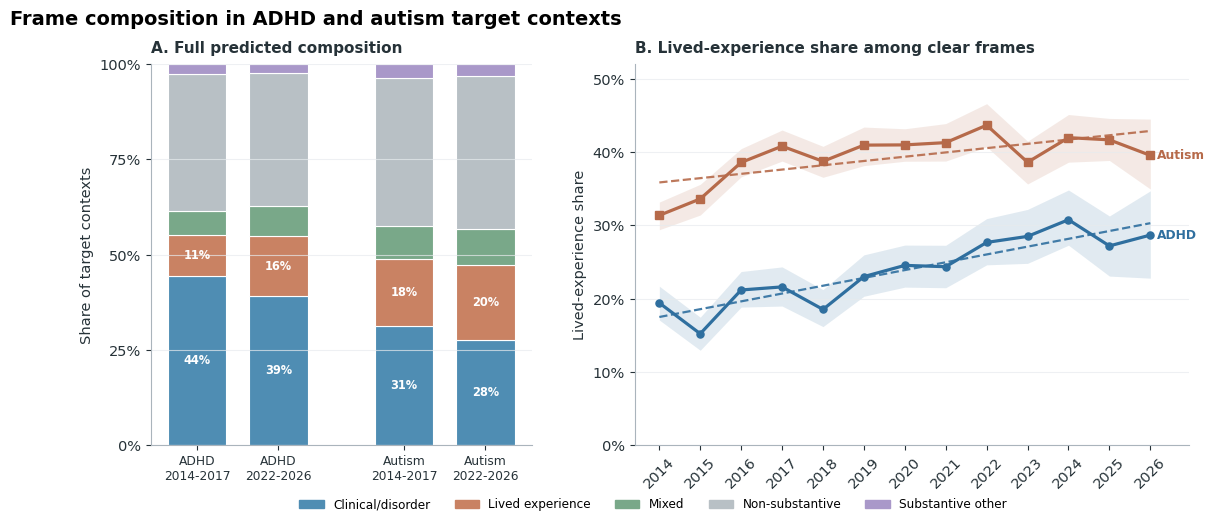

In [5]:
def style_classification_axis(ax: plt.Axes) -> None:
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.spines["left"].set_color("#AAB4BC")
    ax.spines["bottom"].set_color("#AAB4BC")
    ax.grid(axis="y", color="#E7EBEE", linewidth=0.8)
    ax.grid(axis="x", visible=False)


fig, axes = plt.subplots(
    1,
    2,
    figsize=(13.4, 4.95),
    gridspec_kw={"width_ratios": [0.88, 1.28], "wspace": 0.22},
)
composition_ax, trend_ax = axes

# Panel A: full predicted composition in early and late periods.
bar_positions = []
bar_labels = []
bar_position_by_group: dict[tuple[str, str], float] = {}
position = 0.0
for unit in TARGET_UNITS:
    for period in ["2014-2017", "2022-2026"]:
        bar_position_by_group[(unit, period)] = position
        bar_positions.append(position)
        bar_labels.append(f"{unit}\n{period}")
        position += 1.0
    position += 0.55

for unit in TARGET_UNITS:
    for period in ["2014-2017", "2022-2026"]:
        bottom = 0.0
        x = bar_position_by_group[(unit, period)]
        period_data = full_composition_periods.loc[
            full_composition_periods["analysis_unit"].eq(unit) & full_composition_periods["period"].eq(period)
        ]
        for frame in APPENDIX_FRAMES:
            frame_row = period_data.loc[period_data["predicted_derived_frame"].eq(frame)]
            value = float(frame_row["pct_within_target_period"].iloc[0]) if not frame_row.empty else 0.0
            composition_ax.bar(
                x,
                value,
                bottom=bottom,
                width=0.72,
                color=FRAME_COLOURS[frame],
                edgecolor="white",
                linewidth=0.8,
            )
            if frame in {"clinical_only", "lived_only"} and value >= 0.08:
                composition_ax.text(
                    x,
                    bottom + value / 2,
                    f"{value * 100:.0f}%",
                    ha="center",
                    va="center",
                    fontsize=8.2,
                    color="white",
                    fontweight="bold",
                )
            bottom += value

composition_ax.set_title("A. Full predicted composition", loc="left", fontsize=11, fontweight="bold", pad=8)
composition_ax.set_ylabel("Share of target contexts")
composition_ax.set_xticks(bar_positions)
composition_ax.set_xticklabels(bar_labels, fontsize=8.8)
composition_ax.set_ylim(0, 1)
composition_ax.set_yticks([0, 0.25, 0.5, 0.75, 1.0])
composition_ax.set_yticklabels(["0%", "25%", "50%", "75%", "100%"])
style_classification_axis(composition_ax)

# Panel B: clear-frame lived-experience share with document-bootstrap intervals.
for unit in TARGET_UNITS:
    unit_data = frame_balance_figure_data.loc[
        frame_balance_figure_data["analysis_unit"].eq(unit)
        & frame_balance_figure_data["predicted_derived_frame"].eq("lived_only")
    ].sort_values("lsc_year")
    trend_ax.fill_between(
        unit_data["lsc_year"].to_numpy(dtype=float),
        unit_data["share_ci_low"].to_numpy(dtype=float),
        unit_data["share_ci_high"].to_numpy(dtype=float),
        color=TARGET_COLOURS[unit],
        alpha=0.14,
        linewidth=0,
    )
    trend_ax.plot(
        unit_data["lsc_year"],
        unit_data["pct_within_clear_frames"],
        color=TARGET_COLOURS[unit],
        marker=TARGET_MARKERS[unit],
        markersize=5.1,
        linewidth=2.3,
        label=unit,
    )
    trend_ax.plot(
        unit_data["lsc_year"],
        unit_data["fitted_share"],
        color=TARGET_COLOURS[unit],
        linestyle="--",
        linewidth=1.6,
        alpha=0.9,
    )
    final_row = unit_data.iloc[-1]
    trend_ax.text(
        final_row["lsc_year"] + 0.16,
        final_row["pct_within_clear_frames"],
        unit,
        color=TARGET_COLOURS[unit],
        fontsize=8.8,
        fontweight="bold",
        va="center",
    )

trend_ax.set_title("B. Lived-experience share among clear frames", loc="left", fontsize=11, fontweight="bold", pad=8)
trend_ax.set_xlabel("")
trend_ax.set_ylabel("Lived-experience share")
years = sorted(frame_balance_figure_data["lsc_year"].astype(int).unique())
trend_ax.set_xticks(years)
trend_ax.tick_params(axis="x", rotation=45)
trend_ax.set_ylim(0, 0.52)
trend_ax.set_yticks([0, 0.1, 0.2, 0.3, 0.4, 0.5])
trend_ax.set_yticklabels(["0%", "10%", "20%", "30%", "40%", "50%"])
style_classification_axis(trend_ax)

trend_ax.set_xlim(min(years) - 0.6, max(years) + 0.95)

composition_handles = [
    plt.Rectangle((0, 0), 1, 1, color=FRAME_COLOURS[frame], label=FRAME_LABELS[frame])
    for frame in APPENDIX_FRAMES
]

fig.legend(
    handles=composition_handles,
    loc="lower center",
    bbox_to_anchor=(0.5, -0.045),
    ncol=5,
    frameon=False,
    fontsize=8.7,
)
fig.suptitle(
    "Frame composition in ADHD and autism target contexts",
    fontsize=14,
    fontweight="bold",
    x=0.02,
    ha="left",
    y=0.99,
)
fig.tight_layout(rect=[0, 0.12, 1, 0.95])

png_path = FIGURE_DIR / "lsc_classification_frame_balance.png"
pdf_path = FIGURE_DIR / "lsc_classification_frame_balance.pdf"
fig.savefig(png_path, dpi=300, bbox_inches="tight", facecolor="white")
fig.savefig(pdf_path, bbox_inches="tight", facecolor="white")
print(f"Wrote {png_path.relative_to(PROJECT_ROOT)}")
print(f"Wrote {pdf_path.relative_to(PROJECT_ROOT)}")


## Handoff Summary

Use the validation table to describe the classifier's adequacy for substantive-discourse and clinical/lived-experience stratification. Use the frame-balance figure to motivate later frame-aware LSC analyses, and use the appendix composition table to document mixed, non-substantive, and sparse substantive-other labels. The classification layer should not be over-interpreted as lexical semantic change by itself.

In [6]:
summary = {
    "target_contexts": int(len(labels)),
    "adhd_contexts": int(labels["analysis_unit"].eq("ADHD").sum()),
    "autism_contexts": int(labels["analysis_unit"].eq("Autism").sum()),
    "codebook_version": EXPECTED_CODEBOOK_VERSION,
    "figure_panel_a_denominator": "all predicted derived-frame labels",
    "figure_panel_b_denominator": "clinical_only + lived_only",
    "bootstrap_repetitions": BOOTSTRAP_REPETITIONS,
    "bootstrap_unit": "doc_id",
    "adhd_lived_share_slope_pp_per_year": float(
        frame_time_trends.loc[frame_time_trends["analysis_unit"].eq("ADHD"), "linear_slope_pp_per_year"].iloc[0]
    ),
    "autism_lived_share_slope_pp_per_year": float(
        frame_time_trends.loc[frame_time_trends["analysis_unit"].eq("Autism"), "linear_slope_pp_per_year"].iloc[0]
    ),
}
summary


{'target_contexts': 96864,
 'adhd_contexts': 28611,
 'autism_contexts': 68253,
 'codebook_version': 'v0.4',
 'figure_panel_a_denominator': 'all predicted derived-frame labels',
 'figure_panel_b_denominator': 'clinical_only + lived_only',
 'bootstrap_repetitions': 500,
 'bootstrap_unit': 'doc_id',
 'adhd_lived_share_slope_pp_per_year': 1.066593241140112,
 'autism_lived_share_slope_pp_per_year': 0.585180583750184}